# A4.1 Damped Oscillations
<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## Motivation

In the previous phase we studied **ideal oscillations**, where energy continually moves between kinetic and potential forms while the **total mechanical energy remains constant**. In reality, however, oscillations rarely persist forever. Friction, air resistance, electrical resistance, and other dissipative effects gradually remove energy from the system.

These effects are collectively called **damping**. Damping plays a crucial role in many physical systems. It prevents structures from oscillating dangerously after disturbances, allows measuring instruments to settle quickly, and determines how long vibrations persist in musical instruments.

In this section we investigate how dissipative forces modify oscillatory motion and how different levels of damping produce qualitatively different behaviors.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

<div style="background-color:#e6f0ff; padding:15px; border-left:6px solid #003366; border-radius:5px;">

**Definition — Damping Force**

A **damping force** is a force that removes mechanical energy from an oscillating system.  
For many systems at moderate speeds, the damping force is approximately proportional to velocity:

$$
F_d = -b v
$$

where

- $b$ is the **damping coefficient**
- $v$ is the velocity of the oscillator.

The negative sign indicates that the force **opposes the motion**.

</div>

---

## Equation of Motion for a Damped Oscillator

Consider a mass attached to a spring that experiences a damping force proportional to velocity.

Using Newton’s Second Law:

$$
\sum F = m\ddot{x}
$$

The forces acting on the mass are

- spring restoring force: $-kx$
- damping force: $-b\dot{x}$

Thus,

$$
m\ddot{x} = -b\dot{x} - kx
$$

or equivalently,

$$
m\ddot{x} + b\dot{x} + kx = 0
$$

This equation describes the motion of a **damped harmonic oscillator**.

---

## Characteristic Behavior

The behavior of the oscillator depends on the relative strength of the damping compared to the restoring force. Three qualitatively different regimes emerge.

---

<div style="background-color:#e6f0ff; padding:15px; border-left:6px solid #003366; border-radius:5px;">

**Definition — Underdamped Motion**

An oscillator is **underdamped** when damping is small enough that oscillations still occur, but their amplitude gradually decreases over time.

The motion can be written approximately as

$$
x(t) = A e^{-\gamma t}\cos(\omega_d t + \phi)
$$

where

- $\gamma = \frac{b}{2m}$ is the **damping rate**
- $\omega_d$ is the **damped angular frequency**.

The oscillations persist but their amplitude **decays exponentially**.

</div>

---

<div style="background-color:#e6f0ff; padding:15px; border-left:6px solid #003366; border-radius:5px;">

**Definition — Critically Damped Motion**

A system is **critically damped** when the damping is exactly large enough to prevent oscillation while allowing the system to return to equilibrium as quickly as possible.

This type of response is commonly used in

- door closers  
- analog measurement devices  
- mechanical shock absorbers.

</div>

---

<div style="background-color:#e6f0ff; padding:15px; border-left:6px solid #003366; border-radius:5px;">

**Definition — Overdamped Motion**

A system is **overdamped** when damping is so strong that the system returns to equilibrium **slowly without oscillating**.

In this case the motion is monotonic and the return to equilibrium takes longer than in the critically damped case.

</div>

---



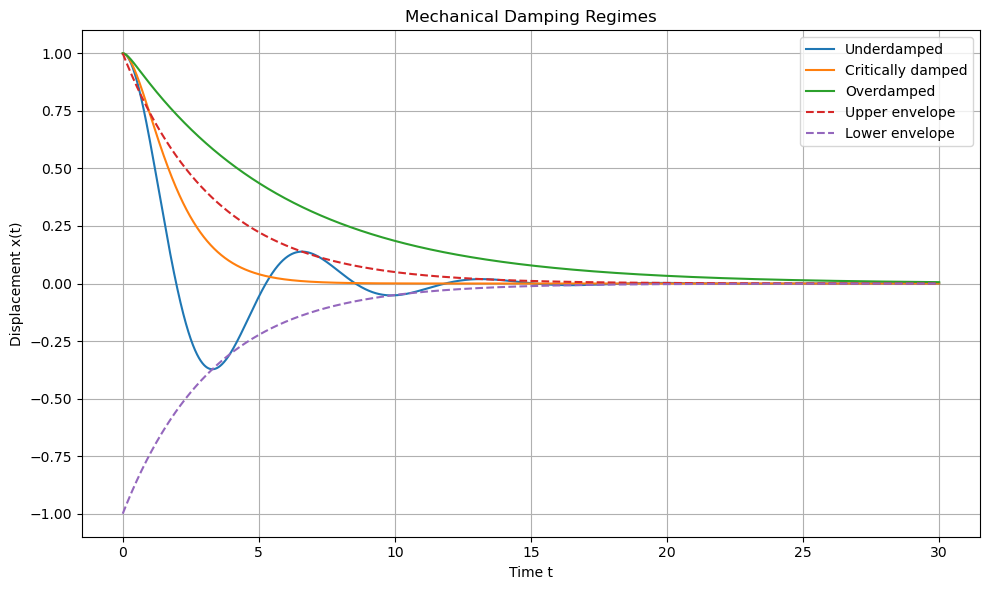

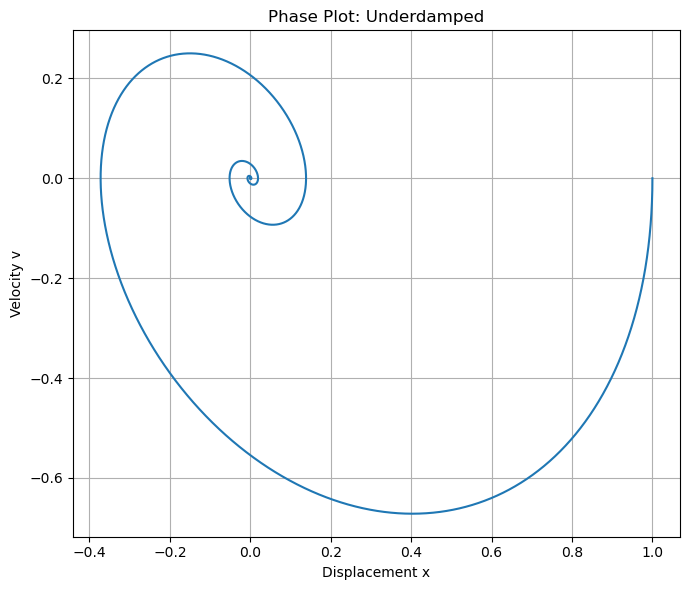

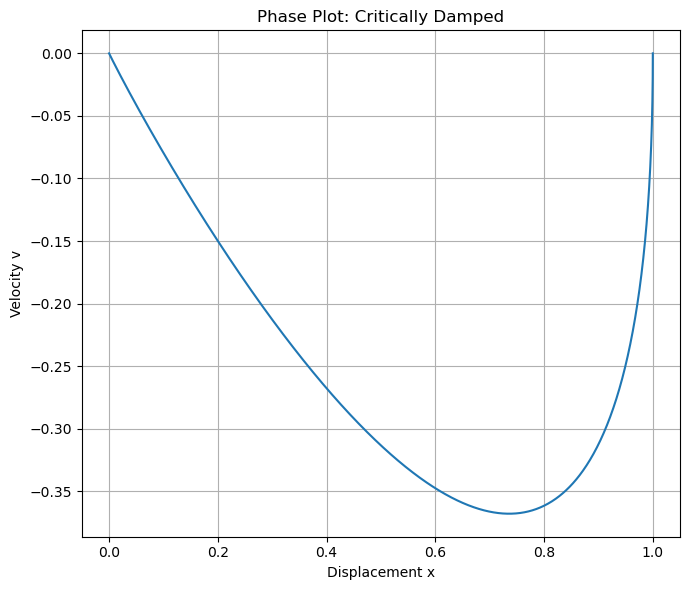

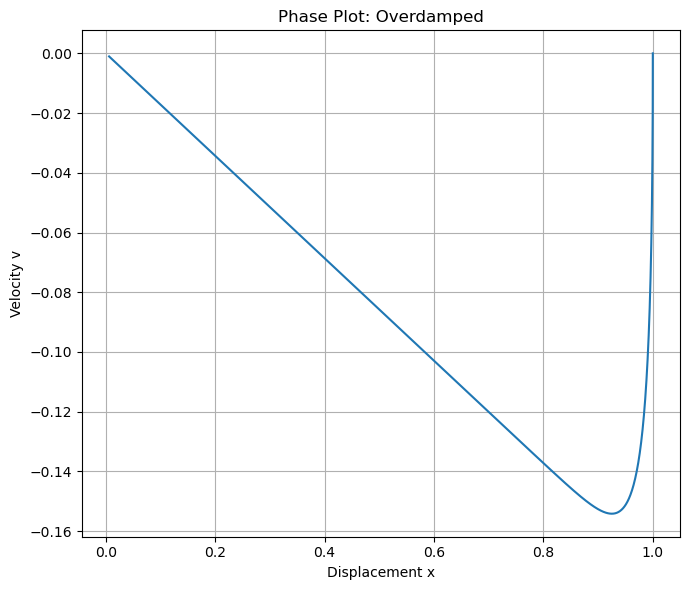

Critical damping coefficient: b_c = 2.0000
Chosen underdamped coefficient: b = 0.6000
Chosen critically damped coefficient: b = 2.0000
Chosen overdamped coefficient: b = 6.0000
Natural angular frequency: omega_0 = 1.0000
Underdamped decay constant: gamma = 0.3000
Underdamped oscillation frequency: omega_d = 0.9539
Underdamped period: T_d = 6.5866


In [1]:
# %reset -f

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Mechanical damping illustration:
#   1) Underdamped
#   2) Critically damped
#   3) Overdamped
#
# Equation:
#     m x'' + b x' + k x = 0
#
# State variables:
#     y = [x, v], where v = dx/dt
# ============================================================

# -----------------------------
# Mechanical parameters
# -----------------------------
m = 1.0
k = 1.0

b_critical = 2 * np.sqrt(m * k)

# Better choices:
b_under = 0.3 * b_critical   # clearly oscillatory
b_crit  = 1.0 * b_critical
b_over  = 3.0 * b_critical

# Initial conditions
x0 = 1.0
v0 = 0.0

# Time array
t_max = 30.0
dt = 0.002
t = np.arange(0, t_max + dt, dt)

# -----------------------------
# RHS of first-order system
# -----------------------------
def mech_rhs(state, b, m, k):
    x, v = state
    dxdt = v
    dvdt = -(b / m) * v - (k / m) * x
    return np.array([dxdt, dvdt], dtype=float)

# -----------------------------
# RK4 solver
# -----------------------------
def solve_mechanical(b, m, k, x0, v0, t):
    y = np.zeros((len(t), 2), dtype=float)
    y[0] = [x0, v0]

    for n in range(len(t) - 1):
        h = t[n + 1] - t[n]
        yn = y[n]

        k1 = mech_rhs(yn, b, m, k)
        k2 = mech_rhs(yn + 0.5 * h * k1, b, m, k)
        k3 = mech_rhs(yn + 0.5 * h * k2, b, m, k)
        k4 = mech_rhs(yn + h * k3, b, m, k)

        y[n + 1] = yn + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return y[:, 0], y[:, 1]

# -----------------------------
# Solve cases
# -----------------------------
x_under, v_under = solve_mechanical(b_under, m, k, x0, v0, t)
x_crit,  v_crit  = solve_mechanical(b_crit,  m, k, x0, v0, t)
x_over,  v_over  = solve_mechanical(b_over,  m, k, x0, v0, t)

# -----------------------------
# Envelope for underdamped case
# -----------------------------
gamma_under = b_under / (2 * m)
envelope = x0 * np.exp(-gamma_under * t)

# -----------------------------
# Plot: time behavior
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(t, x_under, label='Underdamped')
plt.plot(t, x_crit, label='Critically damped')
plt.plot(t, x_over, label='Overdamped')
plt.plot(t, envelope, '--', label='Upper envelope')
plt.plot(t, -envelope, '--', label='Lower envelope')

plt.xlabel('Time t')
plt.ylabel('Displacement x(t)')
plt.title('Mechanical Damping Regimes')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Phase plot: underdamped
# -----------------------------
plt.figure(figsize=(7, 6))
plt.plot(x_under, v_under)
plt.xlabel('Displacement x')
plt.ylabel('Velocity v')
plt.title('Phase Plot: Underdamped')
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Phase plot: critically damped
# -----------------------------
plt.figure(figsize=(7, 6))
plt.plot(x_crit, v_crit)
plt.xlabel('Displacement x')
plt.ylabel('Velocity v')
plt.title('Phase Plot: Critically Damped')
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Phase plot: overdamped
# -----------------------------
plt.figure(figsize=(7, 6))
plt.plot(x_over, v_over)
plt.xlabel('Displacement x')
plt.ylabel('Velocity v')
plt.title('Phase Plot: Overdamped')
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Useful quantities
# -----------------------------
omega0 = np.sqrt(k / m)
gamma = b_under / (2 * m)
omega_d = np.sqrt(omega0**2 - gamma**2)

print(f"Critical damping coefficient: b_c = {b_critical:.4f}")
print(f"Chosen underdamped coefficient: b = {b_under:.4f}")
print(f"Chosen critically damped coefficient: b = {b_crit:.4f}")
print(f"Chosen overdamped coefficient: b = {b_over:.4f}")
print(f"Natural angular frequency: omega_0 = {omega0:.4f}")
print(f"Underdamped decay constant: gamma = {gamma:.4f}")
print(f"Underdamped oscillation frequency: omega_d = {omega_d:.4f}")
print(f"Underdamped period: T_d = {2*np.pi/omega_d:.4f}")

---
## Interpreting Phase Plots

In addition to time-based graphs, we can also represent the behavior of a damped mechanical oscillator using a **phase plot**, where we graph:

$$
v \;\text{vs.}\; x
$$

Since velocity is related to position by

$$
v = \frac{dx}{dt},
$$

each point on this plot represents the **state of the system at a given instant**:

- $x$ tells us “where the system is”
- $v$ tells us “how it is changing”

As time progresses, the system traces out a **trajectory in the $(x,v)$ plane**, called **phase space**.

---

### What Phase Plots Show

A phase plot does not explicitly show time. Instead, it shows:

- The relationship between a variable and its rate of change  
- The overall structure of motion in a single curve  

👉 This makes it possible to identify qualitative behavior immediately:

- Oscillatory vs. non-oscillatory motion  
- Fast vs. slow return to equilibrium  
- Energy exchange between kinetic and potential forms  

---

### Underdamped Case — Spiral Toward the Origin

For the underdamped case:

- The system oscillates while gradually losing energy  

In the phase plot:

- The trajectory forms a **spiral inward**

**Interpretation:**

- Each loop corresponds to one oscillation  
- The decreasing radius reflects **energy dissipation**  
- Motion alternates between:
  - Large $x$, small $v$ $\rightarrow$ energy mostly potential  
  - Small $x$, large $v$ $\rightarrow$ energy mostly kinetic  

👉 The spiral captures both **oscillation and decay** in a single picture.

---

### Critically Damped Case — Direct Approach

For the critically damped case:

- The system returns to equilibrium without oscillating  
- It does so as quickly as possible  

In the phase plot:

- The trajectory moves **directly toward the origin**  
- There are no loops or spirals  

**Interpretation:**

- The system smoothly approaches equilibrium  
- There is no back-and-forth energy exchange  
- The path represents the **optimal balance** between inertia and damping  

---

### Overdamped Case — Slow Approach

For the overdamped case:

- The system does not oscillate  
- It returns to equilibrium more slowly  

In the phase plot:

- The trajectory approaches the origin gradually  
- It does not loop or spiral  

**Interpretation:**

- Strong damping suppresses oscillation  
- Energy is dissipated before repeated motion can develop  
- The system is “over-restrained,” leading to slow evolution  

---

### Why Phase Plots Are Useful

Phase plots provide a powerful way to understand system behavior:

- They combine **position and rate of change** in one view  
- They clearly distinguish between:
  - Oscillatory motion (spirals)  
  - Non-oscillatory motion (direct paths)

- They visualize energy flow:
  - Horizontal extremes (large $x$) $\rightarrow$ spring potential energy  
  - Vertical extremes (large $v$) $\rightarrow$ kinetic energy  

- They reveal the **global behavior** of the system, not just snapshots in time  

---

### Key Insight

A phase plot shows how the system moves through its possible states:

> Instead of tracking motion as a function of time, we see the **structure of the motion itself**.

This perspective provides a deeper understanding of damped mechanical oscillators as **dynamical systems**, connecting mass-spring motion to broader ideas used throughout physics.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## Energy Loss in Oscillations

In an ideal oscillator the total mechanical energy

$$
E = K + U
$$

remains constant.  

With damping present, however, the damping force performs **negative work**, removing energy from the system.

As a result,

- the **amplitude decreases over time**
- the **mechanical energy decays exponentially**

$$
E(t) \propto e^{-2\gamma t}
$$

This explains why oscillations eventually stop in real physical systems.

---

<div style="background-color:#e0f7fa; padding:15px; border-left:6px solid #006a80; border-radius:5px;">

**Example — Shock Absorbers in a Car**

A car suspension system can be modeled as a **mass–spring–damper system**.

- The **spring** supports the weight of the car and allows vertical motion.
- The **shock absorber** provides damping.

Without damping, the car would continue bouncing after hitting a bump.  
With appropriate damping, the oscillations quickly decay and the ride becomes smooth and stable.

</div>

---

<div style="background-color:#e8f5e9; padding:15px; border-left:6px solid #006633; border-radius:5px;">

**Box Activity 1 — Identifying Damping Regimes**

Consider three oscillatory systems:

1. A tuning fork vibrating in air.  
2. A car suspension with worn-out shock absorbers.  
3. A heavy door with a hydraulic closer.

For each system:

1. Predict whether the motion is **underdamped**, **critically damped**, or **overdamped**.
2. Explain the physical reasons for your choice.

<details>
<summary>Discussion</summary>

1. **Tuning fork:** underdamped — oscillations persist for a long time with slow decay.  
2. **Worn suspension:** underdamped — the car continues bouncing after hitting a bump.  
3. **Hydraulic door closer:** close to critically damped — the door returns smoothly without oscillating.

</details>

</div>

---

## Looking Ahead

Damping removes energy from oscillators, but oscillations can also gain energy from external sources. When a system is **periodically driven**, the competition between damping and energy input leads to one of the most important phenomena in physics: **resonance**.

In the next section we study **driven oscillations** and how resonance emerges when the driving frequency approaches the natural frequency of the oscillator.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">